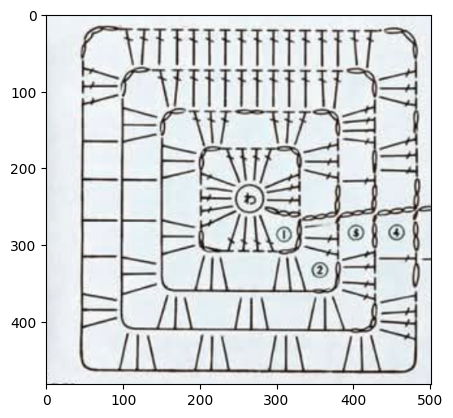

In [185]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import math

img = cv.imread('data/raw/easy/2.png')
plt.imshow(img)

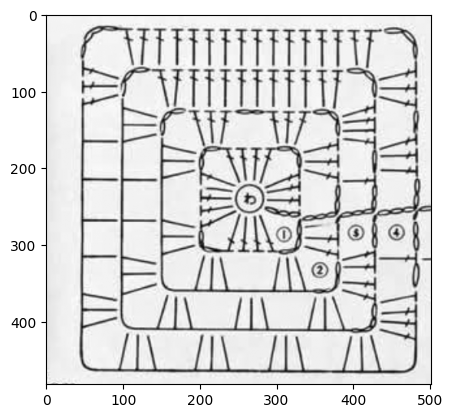

In [186]:
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(gray_img, cmap='gray')

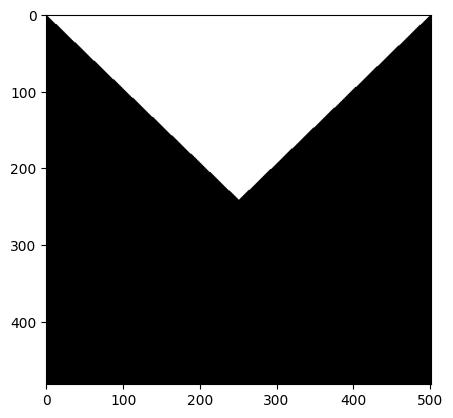

In [187]:
# Create mask for granny square. We need to parse only the top quarter triangle of the image, so we can ignore the rest.
mask = np.zeros(gray_img.shape, dtype=np.uint8)
h, w = gray_img.shape
pts = np.tril(np.array([[0, 0], [w, 0], [w // 2, h // 2]]))
cv.fillPoly(mask, [pts], 255)
plt.imshow(mask, cmap='gray')

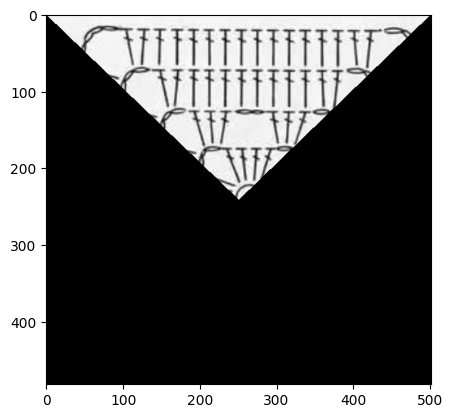

In [188]:
masked_img = cv.bitwise_and(gray_img, gray_img, mask=mask)
plt.imshow(masked_img, cmap='gray')

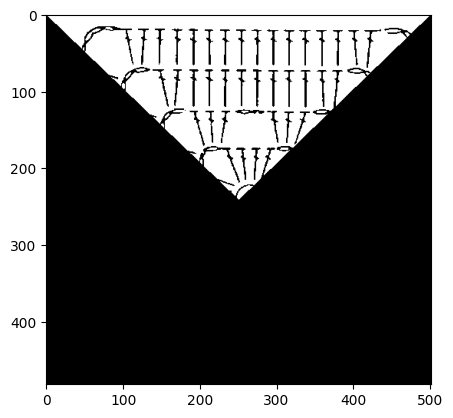

In [189]:
ret,thresh1 = cv.threshold(masked_img,127,255,cv.THRESH_OTSU)
plt.imshow(thresh1, cmap='gray')

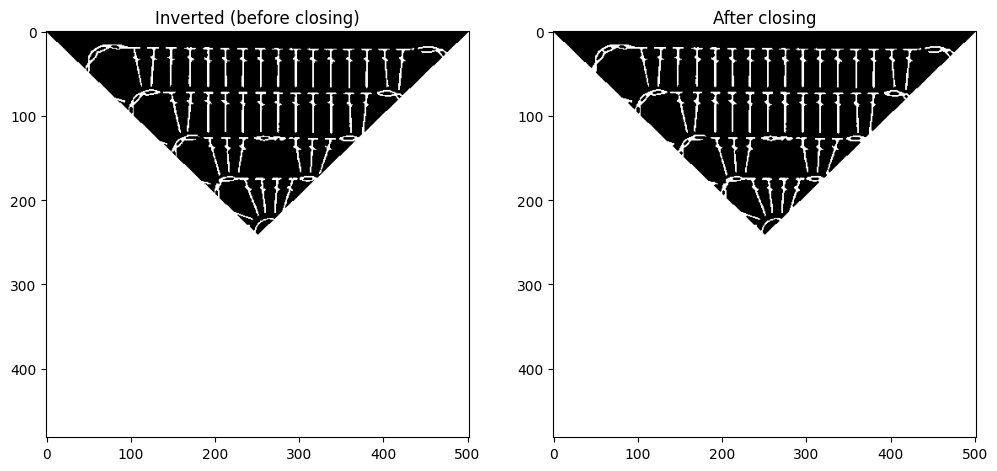

In [190]:
# Invert threshold: white symbols on black background (required for correct morphological closing)
thresh_inv = cv.bitwise_not(thresh1)

# Close small gaps in broken circle outlines
# Now closing expands white symbol lines to bridge gaps, not the background
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
closed = cv.morphologyEx(thresh_inv, cv.MORPH_CLOSE, kernel)

# Compare before and after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(thresh_inv, cmap='gray'); ax1.set_title('Inverted (before closing)')
ax2.imshow(closed, cmap='gray');    ax2.set_title('After closing')
plt.show()

In [191]:
contours, hierarchy = cv.findContours(closed, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

In [192]:
def get_shape_features(c):
    x, y, w, h = cv.boundingRect(c)
    aspect_ratio = w / h                                                          # circles ≈ 1.0, tall stitches << 1
    area = cv.contourArea(c)
    perimeter = cv.arcLength(c, True)
    circularity = (4 * np.pi * area / (perimeter ** 2)) if perimeter > 0 else 0  # circles ≈ 1.0
    return aspect_ratio, circularity, area

# Print all contours so we can tune thresholds
print(f"{'i':>4}  {'area':>8}  {'aspect_ratio':>12}  {'circularity':>12}")
print("-" * 45)
for i, c in enumerate(contours):
    ar, circ, area = get_shape_features(c)
    print(f"{i:>4}  {area:>8.0f}  {ar:>12.3f}  {circ:>12.3f}")

slip_stitch_contours = []
for c in contours:
    aspect_ratio, circularity, area = get_shape_features(c)
    if (
        0.5 < aspect_ratio < 2.0 and  # roughly as wide as tall
        circularity > 0.55 and         # reasonably round (not a bar or tick)
        100 < area < 8000              # large enough to be a real symbol
    ):
        slip_stitch_contours.append(c)

print(f"\nSlip stitches found: {len(slip_stitch_contours)}")

   i      area  aspect_ratio   circularity
---------------------------------------------
   0        84         0.286         0.092
   1        87         0.310         0.095
   2        74         0.293         0.079
   3        84         0.357         0.081
   4        76         0.286         0.080
   5        67         0.262         0.075
   6        84         0.435         0.075
   7       112         5.429         0.200
   8        16         1.400         0.857
   9        86         0.271         0.075
  10       116         0.265         0.099
  11        78         0.292         0.063
  12       114         0.271         0.096
  13       121         0.224         0.107
  14        92         0.271         0.076
  15       109         0.224         0.099
  16        86         0.229         0.077
  17       122         0.245         0.102
  18        94         0.229         0.083
  19        92         0.429         0.064
  20        74         0.304         0.066
  21    

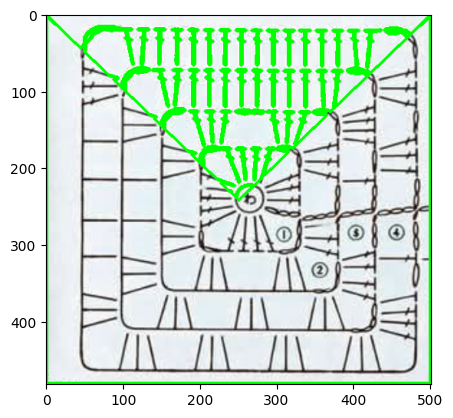

In [193]:
# Draw contours on the original image
img_contours = img.copy()
cv.drawContours(img_contours, contours, -1, (0, 255, 0), 3)
plt.imshow(img_contours)

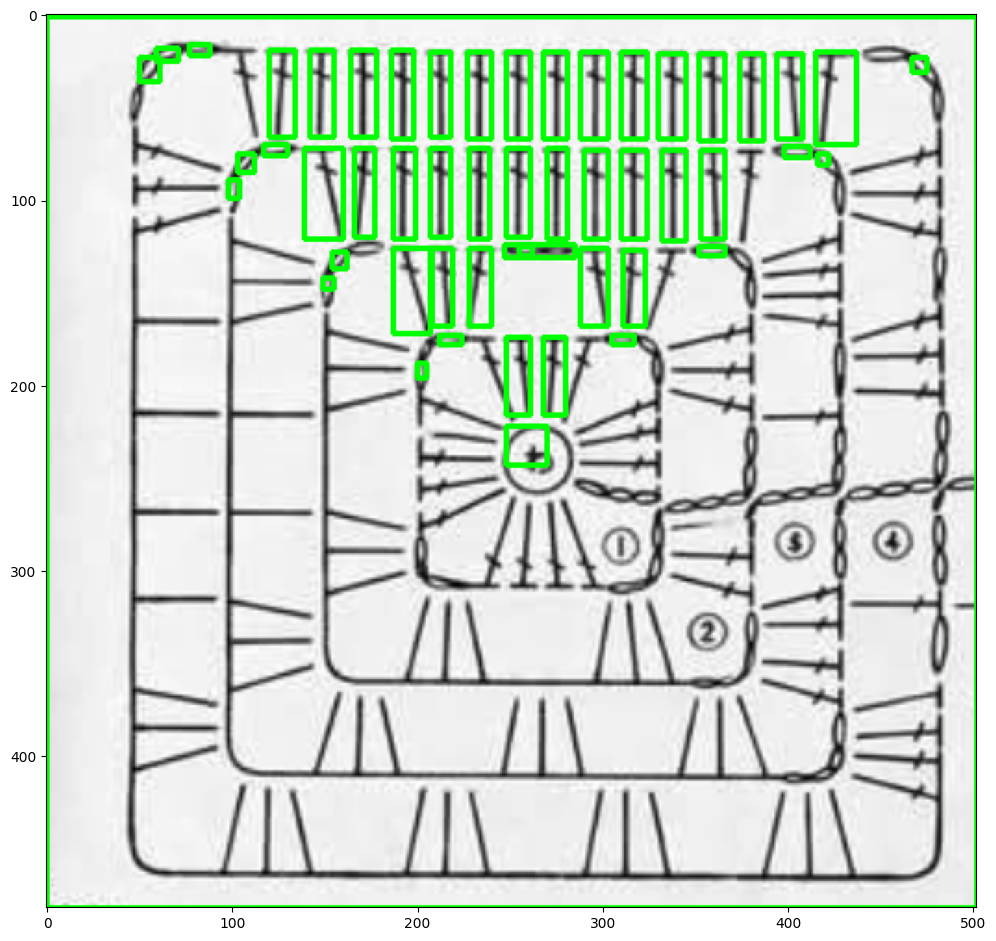

In [194]:
debug_img = cv.cvtColor(gray_img, cv.COLOR_GRAY2BGR)
for c in contours:
    x, y, w, h = cv.boundingRect(c)
    cv.rectangle(debug_img, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.figure(figsize=(12, 12))
plt.imshow(cv.cvtColor(debug_img, cv.COLOR_BGR2RGB))
plt.show()

In [195]:
import os

output_dir = "data/segments/unlabeled"
os.makedirs(output_dir, exist_ok=True)

PADDING = 4  # pixels of padding around each symbol

for i, c in enumerate(contours):
    x, y, w, h = cv.boundingRect(c)
    # Add padding, clamped to image bounds
    x1 = max(x - PADDING, 0)
    y1 = max(y - PADDING, 0)
    x2 = min(x + w + PADDING, gray_img.shape[1])
    y2 = min(y + h + PADDING, gray_img.shape[0])
    
    crop = gray_img[y1:y2, x1:x2]
    cv.imwrite(f"{output_dir}/symbol_{i:04d}.png", crop)

print(f"Saved {len(contours)} crops to {output_dir}/")

Saved 52 crops to data/segments/unlabeled/


In [196]:
import cv2 as cv
import os, shutil

crops_dir = "data/segments/unlabeled"
output_dir = "data/segments/labeled"
symbol_keys = {'c': 'chain', 's': 'slip_stitch', 't': 'treble', 'd': 'double', 'n': 'noise'}

for cls in symbol_keys.values():
    os.makedirs(f"{output_dir}/{cls}", exist_ok=True)

files = [f for f in os.listdir(crops_dir) if f.endswith('.png')]
for i, fname in enumerate(files):
    img = cv.imread(f"{crops_dir}/{fname}")
    cv.imshow(f"[{i+1}/{len(files)}] c=chain s=slip t=treble d=double n=noise", img)
    key = chr(cv.waitKey(0) & 0xFF)
    cv.destroyAllWindows()
    if key in symbol_keys:
        shutil.move(f"{crops_dir}/{fname}", f"{output_dir}/{symbol_keys[key]}/{fname}")
    elif key == 'q':
        break